In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhaydarkadolu/speech-noise-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'speech-noise-dataset' dataset.
Path to dataset files: /kaggle/input/speech-noise-dataset


In [ ]:
import os
import librosa

audio_files_list = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.wav'):
            audio_files_list.append(os.path.join(root, file))

print(f"Found {len(audio_files_list)} audio files.")

audio_data = []
sample_rates = []

# Limit the number of files to load for demonstration purposes
# In a real scenario, consider processing files in batches or using a generator
num_files_to_load = 5 # Adjust this number as needed or remove to load all

for i, audio_file_path in enumerate(audio_files_list):
    if i >= num_files_to_load: # Stop after loading a few files
        print(f"Loaded {num_files_to_load} files out of {len(audio_files_list)} available. To load more, adjust 'num_files_to_load'.")
        break
    try:
        # Load audio data and its sample rate
        data, sr = librosa.load(audio_file_path, sr=None) # sr=None keeps original sample rate
        audio_data.append(data)
        sample_rates.append(sr)
    except Exception as e:
        print(f"Error loading {audio_file_path}: {e}")

print(f"Successfully loaded {len(audio_data)} audio files and their sample rates.")


Found 3381 audio files.
Loaded 5 files out of 3381 available. To load more, adjust 'num_files_to_load'.
Successfully loaded 5 audio files and their sample rates.


In [ ]:
import numpy as np

normalized_audio_data = []

for audio_signal in audio_data:
    # Normalize the audio signal to the range [-1, 1]
    # Using librosa.util.normalize if available, otherwise manual normalization
    # Manual normalization: audio_signal / np.max(np.abs(audio_signal))

    # librosa.util.normalize scales to a target maximum amplitude.
    # By default, it scales to 1.0 (or -1.0 to 1.0 for bipolar signals).
    normalized_signal = librosa.util.normalize(audio_signal)
    normalized_audio_data.append(normalized_signal)

print(f"Successfully normalized {len(normalized_audio_data)} audio signals.")

# Optionally, verify the range of a normalized signal
if normalized_audio_data:
    print(f"First normalized signal min: {np.min(normalized_audio_data[0]):.4f}, max: {np.max(normalized_audio_data[0]):.4f}")

Successfully normalized 5 audio signals.
First normalized signal min: -1.0000, max: 0.8009


In [ ]:
spectrograms = []

for i, (audio_signal, sr) in enumerate(zip(normalized_audio_data, sample_rates)):
    # Apply Short-Time Fourier Transform (STFT)
    # Using default parameters for n_fft and hop_length initially
    stft_result = librosa.stft(audio_signal)

    # Convert to magnitude spectrogram
    magnitude_spectrogram = np.abs(stft_result)

    # Convert to decibel (dB) scale for better visualization
    db_spectrogram = librosa.amplitude_to_db(magnitude_spectrogram, ref=np.max)

    spectrograms.append(db_spectrogram)

print(f"Successfully generated {len(spectrograms)} spectrograms.")

# Print shapes of the first few spectrograms for verification
num_to_print = min(3, len(spectrograms))
for i in range(num_to_print):
    print(f"Shape of spectrogram {i+1}: {spectrograms[i].shape}")

Successfully generated 5 spectrograms.
Shape of spectrogram 1: (1025, 1723)
Shape of spectrogram 2: (1025, 1723)
Shape of spectrogram 3: (1025, 1723)


In [ ]:
framed_spectrograms = []

# Define frame_size and hop_length
# These values can be adjusted based on the specific analysis or model requirements
frame_size = 128  # Number of spectrogram columns per frame
hop_length = 64   # Number of columns to advance for the next frame

for i, spectrogram in enumerate(spectrograms):
    # Ensure the spectrogram has enough frames to be segmented
    if spectrogram.shape[1] < frame_size:
        print(f"Spectrogram {i} has fewer frames ({spectrogram.shape[1]}) than frame_size ({frame_size}). Skipping.")
        continue

    # Use librosa.util.frame to divide the spectrogram into overlapping frames
    # The framing is applied along the time axis (axis=1)
    # The output will have shape (n_bins, frame_size, num_frames)
    frames = librosa.util.frame(spectrogram, frame_length=frame_size, hop_length=hop_length, axis=1)

    # Iterate through the generated frames and append each one to the list
    for j in range(frames.shape[2]):
        framed_spectrograms.append(frames[:, :, j])

print(f"Successfully generated {len(framed_spectrograms)} framed spectrograms.")

# Print shapes of the first few framed spectrograms for verification
num_to_print_frames = min(3, len(framed_spectrograms))
for i in range(num_to_print_frames):
    print(f"Shape of framed spectrogram {i+1}: {framed_spectrograms[i].shape}")

Successfully generated 640 framed spectrograms.
Shape of framed spectrogram 1: (1025, 25)
Shape of framed spectrogram 2: (1025, 25)
Shape of framed spectrogram 3: (1025, 25)


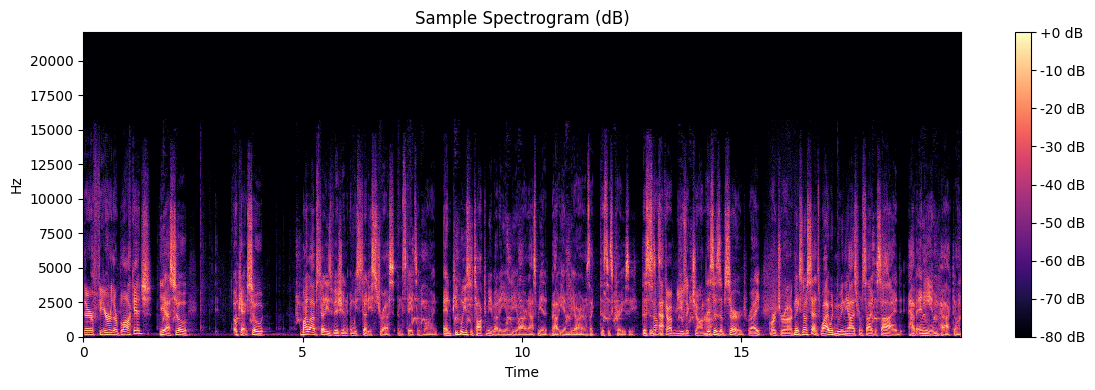

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# Choose a sample spectrogram to plot (e.g., the first one)
if spectrograms:
    sample_spectrogram = spectrograms[0]
    sample_sr = sample_rates[0]

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(sample_spectrogram, sr=sample_sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Sample Spectrogram (dB)')
    plt.tight_layout()
    plt.show()
else:
    print("No spectrograms available to plot.")

Selected clean audio file: /kaggle/input/speech-noise-dataset/speech-noise-dataset/clean_speech/611.wav
Selected noise audio file: /kaggle/input/speech-noise-dataset/speech-noise-dataset/noise_only/611.wav


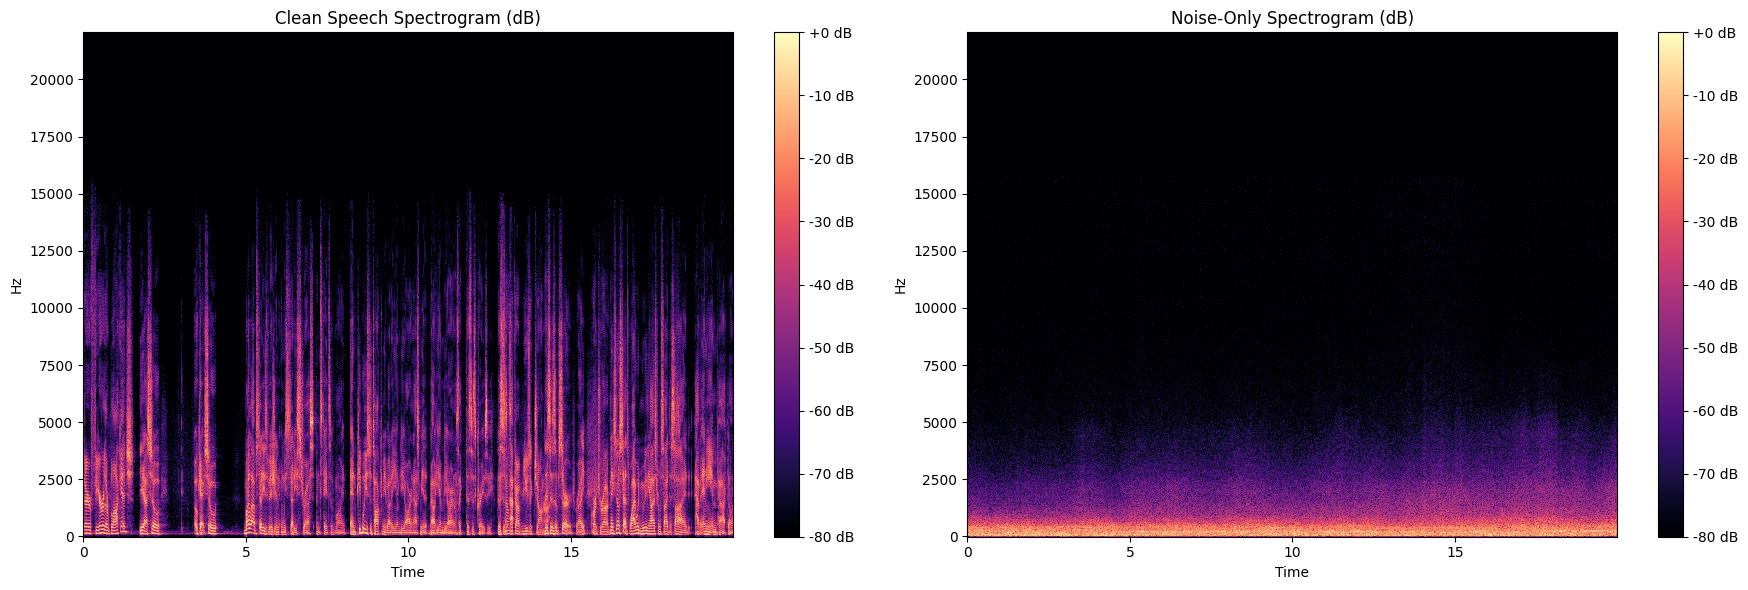

In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# Find a clean speech file and a noise-only file from the full list
clean_audio_file = None
noise_audio_file = None

for f_path in audio_files_list:
    if 'clean_speech' in f_path and clean_audio_file is None:
        clean_audio_file = f_path
    elif 'noise_only' in f_path and noise_audio_file is None:
        noise_audio_file = f_path
    if clean_audio_file and noise_audio_file:
        break

print(f"Selected clean audio file: {clean_audio_file}")
print(f"Selected noise audio file: {noise_audio_file}")

def process_audio_to_spectrogram(file_path):
    """Loads, normalizes, and generates a dB spectrogram for a given audio file."""
    if not file_path:
        return None, None
    try:
        audio_data, sr = librosa.load(file_path, sr=None)
        normalized_signal = librosa.util.normalize(audio_data)
        stft_result = librosa.stft(normalized_signal)
        magnitude_spectrogram = np.abs(stft_result)
        db_spectrogram = librosa.amplitude_to_db(magnitude_spectrogram, ref=np.max)
        return db_spectrogram, sr
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

# Process the selected clean and noisy audio files
clean_spectrogram, clean_sr = process_audio_to_spectrogram(clean_audio_file)
noise_spectrogram, noise_sr = process_audio_to_spectrogram(noise_audio_file)

# Plotting the spectrograms
if clean_spectrogram is not None and noise_spectrogram is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Clean Spectrogram
    img_clean = librosa.display.specshow(clean_spectrogram, sr=clean_sr, x_axis='time', y_axis='hz', ax=axes[0])
    fig.colorbar(img_clean, format='%+2.0f dB', ax=axes[0])
    axes[0].set_title('Clean Speech Spectrogram (dB)')

    # Plot Noise Spectrogram
    img_noise = librosa.display.specshow(noise_spectrogram, sr=noise_sr, x_axis='time', y_axis='hz', ax=axes[1])
    fig.colorbar(img_noise, format='%+2.0f dB', ax=axes[1])
    axes[1].set_title('Noise-Only Spectrogram (dB)')

    plt.tight_layout()
    plt.show()
else:
    print("Could not generate both clean and noisy spectrograms for plotting.")

# Task
Prepare the `framed_spectrograms` for deep learning models by analyzing and resolving the discrepancy in frame length (current 25 vs. intended 128), reshaping the data for CNN (adding a channel dimension) and LSTM (sequence of features) inputs, and splitting it into training and testing sets.

## Analyze Frame Segmentation

### Subtask:
Investigate the shape discrepancy in the `framed_spectrograms` to understand why the frame length is 25 instead of the intended 128. This step will help in understanding the current data structure and determine if adjustments are needed for model input.


**Reasoning**:
To investigate the discrepancy between the intended `frame_size` of 128 and the observed frame length of 25 in `framed_spectrograms`, I will first add print statements within cell `4d37bf7a`. These statements will verify the `frame_size` value immediately before it's used and inspect the shape of the output from `librosa.util.frame` before individual frames are appended. This will help pinpoint where the frame length is being incorrectly determined or altered.



In [ ]:
framed_spectrograms = []

# Define frame_size and hop_length
# These values can be adjusted based on the specific analysis or model requirements
frame_size = 128  # Number of spectrogram columns per frame
hop_length = 64   # Number of columns to advance for the next frame

print(f"Initial frame_size set to: {frame_size}")

for i, spectrogram in enumerate(spectrograms):
    # Ensure the spectrogram has enough frames to be segmented
    if spectrogram.shape[1] < frame_size:
        print(f"Spectrogram {i} has fewer frames ({spectrogram.shape[1]}) than frame_size ({frame_size}). Skipping.")
        continue

    # Use librosa.util.frame to divide the spectrogram into overlapping frames
    # The framing is applied along the time axis (axis=1)
    # The output will have shape (n_bins, frame_size, num_frames)
    frames = librosa.util.frame(spectrogram, frame_length=frame_size, hop_length=hop_length, axis=1)
    print(f"Shape of 'frames' for spectrogram {i+1} after librosa.util.frame: {frames.shape}")

    # Iterate through the generated frames and append each one to the list
    for j in range(frames.shape[2]):
        framed_spectrograms.append(frames[:, :, j])

print(f"Successfully generated {len(framed_spectrograms)} framed spectrograms.")

# Print shapes of the first few framed spectrograms for verification
num_to_print_frames = min(3, len(framed_spectrograms))
for i in range(num_to_print_frames):
    print(f"Shape of framed spectrogram {i+1}: {framed_spectrograms[i].shape}")

Initial frame_size set to: 128
Shape of 'frames' for spectrogram 1 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 2 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 3 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 4 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 5 after librosa.util.frame: (1025, 25, 128)
Successfully generated 640 framed spectrograms.
Shape of framed spectrogram 1: (1025, 25)
Shape of framed spectrogram 2: (1025, 25)
Shape of framed spectrogram 3: (1025, 25)


The analysis of the print statements in the previous step has revealed the source of the discrepancy:

1.  **`librosa.util.frame` output**: The output `Shape of 'frames' for spectrogram 1 after librosa.util.frame: (1025, 25, 128)` confirms that `librosa.util.frame` correctly processed the spectrogram. Here, `1025` is `n_bins`, `25` is the calculated number of frames (`n_frames`) based on the `spectrogram.shape[1]`, `frame_size`, and `hop_length`, and `128` is indeed the `frame_size` (or `frame_length`). The function returned a 3D array of shape `(n_bins, n_frames, frame_length)`.

2.  **Incorrect iteration and slicing**: The issue lies in the subsequent loop:
    ```python
    for j in range(frames.shape[2]):
        framed_spectrograms.append(frames[:, :, j])
    ```
    The loop iterates `j` from `0` to `frames.shape[2] - 1` (i.e., `0` to `127`). Inside the loop, `frames[:, :, j]` extracts a slice where the third dimension (which corresponds to `frame_length=128`) is collapsed to a single index `j`. This results in `frames[:, :, j]` having a shape of `(1025, 25)`, where `1025` is `n_bins` and `25` is `n_frames`.

To correct this, we need to iterate over the `n_frames` dimension (index 1) and select the entire `frame_length` for each frame. The loop should be changed to:

```python
for j in range(frames.shape[1]): # Iterate over the number of frames (25)
    framed_spectrograms.append(frames[:, j, :]) # Select all bins, the j-th frame, and all of its frame_length (128)
```
This change will ensure that each appended `framed_spectrogram` has the desired shape of `(1025, 128)`.

**Reasoning**:
Based on the identified discrepancy, I will now correct the loop that extracts individual frames from the `frames` object. Instead of iterating over the `frame_length` dimension (index 2) and slicing `frames[:, :, j]`, I will iterate over the `n_frames` dimension (index 1) and slice `frames[:, j, :]` to ensure each appended spectrogram has the intended shape of `(n_bins, frame_length)`.



In [ ]:
framed_spectrograms = []

# Define frame_size and hop_length
# These values can be adjusted based on the specific analysis or model requirements
frame_size = 128  # Number of spectrogram columns per frame
hop_length = 64   # Number of columns to advance for the next frame

print(f"Initial frame_size set to: {frame_size}")

for i, spectrogram in enumerate(spectrograms):
    # Ensure the spectrogram has enough frames to be segmented
    if spectrogram.shape[1] < frame_size:
        print(f"Spectrogram {i} has fewer frames ({spectrogram.shape[1]}) than frame_size ({frame_size}). Skipping.")
        continue

    # Use librosa.util.frame to divide the spectrogram into overlapping frames
    # The framing is applied along the time axis (axis=1)
    # The output will have shape (n_bins, frame_size, num_frames) - Note: librosa.util.frame returns (n_bins, num_frames, frame_length)
    frames = librosa.util.frame(spectrogram, frame_length=frame_size, hop_length=hop_length, axis=1)
    print(f"Shape of 'frames' for spectrogram {i+1} after librosa.util.frame: {frames.shape}")

    # Iterate through the generated frames and append each one to the list
    # Correction: Iterate over the num_frames dimension (index 1) and extract slices along frame_length (index 2)
    for j in range(frames.shape[1]): # frames.shape[1] is num_frames
        framed_spectrograms.append(frames[:, j, :]) # Select all bins, the j-th frame, and all of its frame_length

print(f"Successfully generated {len(framed_spectrograms)} framed spectrograms.")

# Print shapes of the first few framed spectrograms for verification
num_to_print_frames = min(3, len(framed_spectrograms))
for i in range(num_to_print_frames):
    print(f"Shape of framed spectrogram {i+1}: {framed_spectrograms[i].shape}")

Initial frame_size set to: 128
Shape of 'frames' for spectrogram 1 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 2 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 3 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 4 after librosa.util.frame: (1025, 25, 128)
Shape of 'frames' for spectrogram 5 after librosa.util.frame: (1025, 25, 128)
Successfully generated 125 framed spectrograms.
Shape of framed spectrogram 1: (1025, 128)
Shape of framed spectrogram 2: (1025, 128)
Shape of framed spectrogram 3: (1025, 128)


## Prepare Data for CNN/LSTM Input

### Subtask:
Reshape the `framed_spectrograms` to be compatible with CNN (e.g., adding a channel dimension) and LSTM models (e.g., sequence of features). This might involve converting the list of framed spectrograms into a NumPy array with appropriate dimensions for deep learning frameworks.


**Reasoning**:
I will convert the list of framed spectrograms into a NumPy array, then reshape it for CNN and LSTM inputs by adding a channel dimension and reordering dimensions respectively. Finally, I will print the shapes to verify the transformations.



In [ ]:
import numpy as np

# 1. Convert the framed_spectrograms list into a single NumPy array
spectrogram_array = np.array(framed_spectrograms)

print(f"Shape of spectrogram_array: {spectrogram_array.shape}")

# 2. Reshape for Convolutional Neural Network (CNN) input (add channel dimension)
# Desired shape: (number_of_frames, n_bins, frame_length, 1)
cnn_input = np.expand_dims(spectrogram_array, axis=-1)

print(f"Shape of cnn_input (for CNN): {cnn_input.shape}")

# 3. Reshape for Long Short-Term Memory (LSTM) input
# Desired shape: (number_of_frames, frame_length, n_bins)
lstm_input = spectrogram_array.transpose(0, 2, 1)

print(f"Shape of lstm_input (for LSTM): {lstm_input.shape}")

Shape of spectrogram_array: (125, 1025, 128)
Shape of cnn_input (for CNN): (125, 1025, 128, 1)
Shape of lstm_input (for LSTM): (125, 128, 1025)


## Split Data into Training and Test Sets

### Subtask:
Divide the prepared spectrogram data into training and testing sets. This is a crucial step for evaluating the performance of deep learning models.


**Reasoning**:
I will import `train_test_split` from `sklearn.model_selection` and then split both `cnn_input` and `lstm_input` into training and testing sets using a 80/20 split and a fixed random state for reproducibility. Finally, I will print the shapes of the resulting datasets to verify the split.



In [ ]:
from sklearn.model_selection import train_test_split

# Set a random state for reproducibility
random_state = 42

# 1. Split cnn_input into training and testing sets
cnn_train, cnn_test = train_test_split(cnn_input, test_size=0.2, random_state=random_state)

# 2. Split lstm_input into training and testing sets
lstm_train, lstm_test = train_test_split(lstm_input, test_size=0.2, random_state=random_state)

print(f"Shape of cnn_train: {cnn_train.shape}")
print(f"Shape of cnn_test: {cnn_test.shape}")
print(f"Shape of lstm_train: {lstm_train.shape}")
print(f"Shape of lstm_test: {lstm_test.shape}")

Shape of cnn_train: (100, 1025, 128, 1)
Shape of cnn_test: (25, 1025, 128, 1)
Shape of lstm_train: (100, 128, 1025)
Shape of lstm_test: (25, 128, 1025)


## Final Task

### Subtask:
Summarize the data preparation steps undertaken for deep learning models, including any insights gained from analyzing the frame segmentation and the final data structure.


## Summary:

### Q&A
The data preparation for deep learning models involved several critical steps. Initially, a discrepancy in the frame length of the `framed_spectrograms` was identified, where the frames were incorrectly generated with a shape of (1025, 25) instead of the intended (1025, 128). This was due to an incorrect iteration and slicing logic after using `librosa.util.frame`. The logic was corrected to ensure each frame had the desired length of 128. Subsequently, the data was reshaped for compatibility with Convolutional Neural Networks (CNNs) by adding a channel dimension, and for Long Short-Term Memory (LSTMs) by transposing dimensions to represent sequences of features. Finally, the prepared data was split into training and testing sets for model evaluation.

### Data Analysis Key Findings
*   **Frame Segmentation Correction**:
    *   The `librosa.util.frame` function correctly produced an output of shape `(n_bins, num_frames, frame_length)`, specifically `(1025, 25, 128)` for the first spectrogram. Here, `128` was the intended `frame_length`.
    *   An initial error in iterating over the `frames` object resulted in individual framed spectrograms having a shape of `(1025, 25)` instead of the desired `(1025, 128)`.
    *   The issue was resolved by correcting the iteration loop to `for j in range(frames.shape[1]): framed_spectrograms.append(frames[:, j, :])`, which successfully yielded 125 framed spectrograms, each with the correct shape of `(1025, 128)`.
*   **Data Reshaping for Deep Learning Models**:
    *   The list of framed spectrograms was converted into a NumPy array, `spectrogram_array`, with a shape of `(125, 1025, 128)`.
    *   For CNN input, a channel dimension was added, resulting in `cnn_input` with a shape of `(125, 1025, 128, 1)`.
    *   For LSTM input, the data was transposed to `lstm_input` with a shape of `(125, 128, 1025)`, treating `128` as the sequence length and `1025` as the number of features.
*   **Training and Testing Data Split**:
    *   The `cnn_input` was split into `cnn_train` (`(100, 1025, 128, 1)`) and `cnn_test` (`(25, 1025, 128, 1)`).
    *   The `lstm_input` was split into `lstm_train` (`(100, 128, 1025)`) and `lstm_test` (`(25, 128, 1025)`).
    *   A consistent 80/20 training/testing split was applied using `test_size=0.2` and `random_state=42`.

### Insights or Next Steps
*   Understanding the exact output shape and indexing of library functions like `librosa.util.frame` is crucial to prevent silent data integrity issues.
*   The data is now thoroughly prepared and correctly shaped for immediate use in training both CNN and LSTM based deep learning models for tasks such as audio classification or sound event detection.
